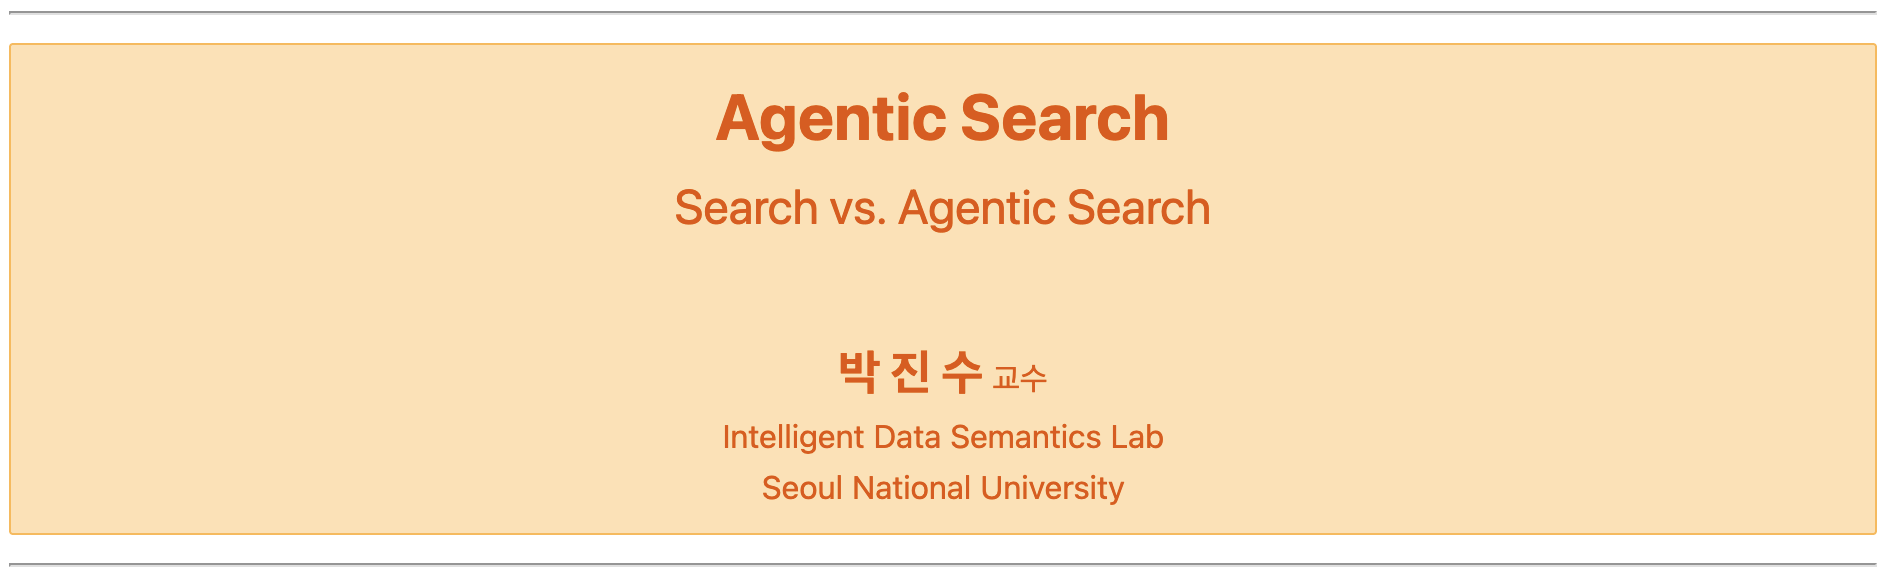

- - -    

- 본 자료는 강의를 위한 목적으로 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Setting-up-Search-API" data-toc-modified-id="Setting-up-Search-API-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Setting up Search API</a></span></li><li><span><a href="#개요" data-toc-modified-id="개요-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>개요</a></span></li><li><span><a href="#일반-검색" data-toc-modified-id="일반-검색-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>일반 검색</a></span></li><li><span><a href="#에이전트-검색" data-toc-modified-id="에이전트-검색-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>에이전트 검색</a></span></li></ul></div>

# Setting up Search API

In [ ]:
!python -m pip install python-dotenv tavily-python ddgs
print('--- Installation Completed', '-' * 55, '\n')

**<font size='+1'>API Key 발급</font>**
- API Key 발급 및 Tavily에 대한 내용은 아래 자료를 참고한다.
  - https://drive.google.com/file/d/121GfCnU7oerwJxabrAdQ-IHsxAgzDp-E/view?usp=sharing
- API Key를 Colab의 보안 비밀에 'TAVILY_API_KEY'라는 이름으로 등록한다.

In [4]:
# --- 방법 1
import os
from tavily import TavilyClient
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv('.api-keys')) 
client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))

In [ ]:
# --- 방법 2 - API Key를 입력한다.
import os, getpass
from tavily import TavilyClient
os.environ['TAVILY_API_KEY'] = getpass.getpass('Enter Your Tavily API Key: ')
client = TavilyClient()

# 개요 

In [2]:
query = '이순신 장군은 누군가요?'
results = client.search(query)
results

{'query': '이순신 장군은 누구있나요?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://ko.wikipedia.org/wiki/%EC%9D%B4%EC%88%9C%EC%8B%A0',
   'title': '이순신 - 위키백과, 우리 모두의 백과사전',
   'content': '이순신(李舜臣, 1545년 4월 28일 (음력 3월 8일)~1598년 12월 16일 (음력 11월 19일)은 조선 중기 한국의 무신이다. 본관은 덕수(德水), 자는 여해(汝諧),',
   'score': 0.6803909,
   'raw_content': None},
  {'url': 'https://www.kculture.or.kr/brd/board/252/L/menu/465?brdType=R&thisPage=17&bbIdx=8541&rootCate=&searchField=&searchText=&recordCnt=10',
   'title': '충무 이순신 (忠武 李舜臣) - 이름별 문화인물',
   'content': '이순신 장군은 조선조 인종 원년 1545년 음력 3월 8일(당시 양력 4월 28일) 서울 건천동(지금의 중구 인현동 부근)에서 아버지 이정(李貞)과 어머니 초계변씨(草溪卞',
   'score': 0.6685563,
   'raw_content': None},
  {'url': 'https://m.blog.naver.com/koreamof/220694635249',
   'title': '충무공 탄신일, 이순신 장군 - 네이버 블로그',
   'content': '이순신 장군은 조선 중기의 무신인데요. 어릴 때부터 무인의 자질을 보였으나 처음 이순신 장군은 문과 응시를 준비했었다고 합니다. 10세 전후부터',
   'score': 0.6396691,
   'raw_content': None},
  {'url': 'https://newsteach

In [3]:
query = '이순신 장군은 누군가요?'
results = client.search(query=query, include_answer=True)
results['answer']

'이순신 장군은 1545년 4월 28일에 태어나 1598년 12월 16일에 순국한 조선의 무장이며, 임진왜란에서 명량대첩, 한산도대첩, 노량해전에서 승리했습니다.'

In [4]:
results

{'query': '이순신 장군은 누군가요?',
 'follow_up_questions': None,
 'answer': '이순신 장군은 1545년 4월 28일에 태어나 1598년 12월 16일에 순국한 조선의 무장이며, 임진왜란에서 명량대첩, 한산도대첩, 노량해전에서 승리했습니다.',
 'images': [],
 'results': [{'url': 'https://blog.naver.com/wisebear99/222411381922?viewType=pc',
   'title': '이순신장군, 그는 누구인가? : 네이버 블로그',
   'content': '이순신장군, 그는 누구인가? 이순시의 가문은 3대 때에. 조선왕조로 넘어오게 되면서. 그 두각을 나타나게 되는데. 5대조인 이변은 영중추부사와. 흥문관',
   'score': 0.9993333,
   'raw_content': None},
  {'url': 'https://www.youtube.com/watch?v=SzBnKrossO8',
   'title': '이순신 장군에 대해 우리가 잘 모르고 있던 사실들 - YouTube',
   'content': '이순신 장군님 너무 존경해서 통영 한산도,아산 현충사 및 묘소, 명량해전 (진도,해남), 노량해전 (남해) 전부 다녀왔네요 전투가 치였 했던 바다 및',
   'score': 0.99847525,
   'raw_content': None},
  {'url': 'https://www.nculture.org/pst/culturePostDetail.do?targetId=154',
   'title': '조선의 무장 충무공 이순신 탄신일 - 지역N문화 | 포스트 큐레이션',
   'content': '... 이순신 장군은 뛰어난 애국정신으로 나라를 지켜내 조선의 명장입니다. 이순신 장군은 3대 대첩이라 불리우는 명량대첩, 한산도대첩, 노량해첩에서 승리하며 왜군',
   'score': 0.9951703,
   'raw_content': None},
  {'u

# 일반 검색

In [6]:
from ddgs import DDGS  

ddg = DDGS()

query = '이순신 장군은 누군가요?'
results = ddg.text(query)  
for result in results:
    print(result)

{'title': '이순신 (1553년) - 위키백과, 우리 모두의 백과사전', 'href': 'https://ko.wikipedia.org/wiki/이순신_(1553년)', 'body': '1 week ago - 임진왜란 때에 활동하던 장수로 그의 상관이기도 했던 충무공 이순신(李舜臣), 등림수 이순신(李舜臣) 등과의 구별을 위해 무의공 이순신, 입부 이순신으로 불린다. 본관은 전주. 양녕대군의 다섯째 서자 장평도정(長平都正)의 ...'}
{'title': '이순신 - 위키백과, 우리 모두의 백과사전', 'href': 'https://ko.wikipedia.org/wiki/이순신', 'body': '5 days ago - 이용은 그의 근무성적을 최하로 매겼는데, 전라도도사(都事)로 재직 중이던 조헌(趙憲)은 고과내용을 보자 부당한 처사라며 항의하여 수정하게 했다. 나중에 이순신의 인물됨을 알아본 이용은 생각을 바꾸어, 함경남도 남병사로 전근한 뒤 1583년 이순신을 자신의 군관으로 추천하기도 했고, 건원보 권관(乾原堡權管)으로 천거하였다.'}
{'title': '이순신(李舜臣) - 한국민족문화대백과사전', 'href': 'https://encykorea.aks.ac.kr/Article/E0044900', 'body': '이순신은 조선시대 정읍현감, 진도군수, 전라좌도 수군절도사 등을 역임한 무신이다. 1545년(명종 즉위)에 태어나 1598년(선조 31)에 사망했다.'}
{'title': '이순신/평가 - 나무위키', 'href': 'https://namu.wiki/w/이순신/평가', 'body': '1 month ago - 넬슨 같은 자는 인격에서 도저히 비견할 수 없다. 이순신 장군은 실로 장갑함(裝甲艦)의 창조자로서, 3백년 이전에 이미 훌륭한 해군전술로 싸운 장수이다." (김준배 2018.'}
{'title': '이순신 1545 ~ 1598 - 우리역사넷', 'href': 'https://contents.history.go.kr/mobile/kc/vi

In [7]:
# 검색 결과에서 url만 추출한다.
for result in results:
    print(result['href'])

https://ko.wikipedia.org/wiki/이순신_(1553년)
https://ko.wikipedia.org/wiki/이순신
https://encykorea.aks.ac.kr/Article/E0044900
https://namu.wiki/w/이순신/평가
https://contents.history.go.kr/mobile/kc/view.do?levelId=kc_n309000&code=kc_age_30
http://koreanschoolaa.org/sites/default/files/+용감한+이순신(김예련).pdf
https://namu.wiki/w/이순신/생애
https://www.nculture.org/pst/culturePostDetail.do?targetId=154
https://m.blog.naver.com/aha05113/223300520235
https://m.blog.naver.com/koreamof/220694635249


In [8]:
import requests
from bs4 import BeautifulSoup

URL = 'https://ko.wikipedia.org/wiki/이순신'
headers = {
    'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'
}
response = requests.get(URL, headers=headers)
bs = BeautifulSoup(response.text, 'html.parser')

# div 태그 중 id가 bodyContent인 첫 번째 요소를 탐색하여 변수 body에 저장한다.
body = bs.find('div', id='bodyContent')

# body의 하위에 있는 모든 <h1>, <h2>, <h3>, <p>태그를 탐색하여 변수 texts에 저장한다.
texts = body.find_all(['h1', 'h2', 'h3', 'p'])

# 리스트 texts 안의 각 객체에 대해 HTML 코드를 제거하고 내용 텍스트만 리스트로 추가한다.
texts = [text.get_text(separator=' ', strip=True) for text in texts]

# 모든 내용을 단일 문자열로 결합한다.
texts = '\n'.join(texts)

In [9]:
# 결합한 텍스트에서 여러 개의 연속된 공백 문자를 단일 공백 문자로 대체한다.
import re

texts = re.sub(r'\s+', ' ', texts)  # \s는 공백 문자를 의미하고, +는 1회 이상 반복을 뜻한다.
print(f'Website: {URL}\n')
print(f'내용:\n{texts}')

Website: https://ko.wikipedia.org/wiki/이순신

내용:
이순신 (李舜臣, 1545년 4월 28일 ( 음력 3월 8일 )~ 1598년 12월 16일 ( 음력 11월 19일 )은 조선 중기 한국 의 무신이다. 본관 은 덕수 (德水), 자 는 여해 (汝諧), 시호 는 충무 (忠武)이며 한성 출신이다. 문반 가문 출신으로 1576년(선조 9년) 무과(武科)에 급제하여 함경도 동구비보 권관(종9품)을 시작으로 훈련원 봉사(종8품), 충청병사 군관, 전라도 발포진 수군만호(종4품), 훈련원 봉사(종8품), 함경남병사 군관, 훈련원 참군(정7품), 사복시 주부(종6품), 함경도 조산보 병마만호(종4품), 전라감사 조방장, 선전관, 전라도 정읍현감(종6품:태인현감 겸무), 전라좌도수군절도사(정3품)를 거쳐 정헌대부(정2품상계) 삼도수군통제사(종2품)에 이르렀다. [ 2 ] 함경도 동구비보권관(董仇非堡權管), 1581년 발포 수군만호(鉢浦水軍萬戶)가 되었다가 전라남수영 의 오동나무를 베기를 거절하여 좌수사 성박의 미움을 받기도 했다. 이후 1584년 남병사의 군관과 건원보권관, 훈련원 참군, 1586년 사복시 주부를 거쳐 조산보만호 겸 녹도둔전사의(造山堡萬戶兼鹿島屯田事宜)로 부임했다. 조산만호 겸 녹둔도사의 재직 중 1587년(선조 20년) 9월 의 여진족 의 사전 기습공격으로 벌어진 녹둔도전투에서 이겼지만 피해가 커서, 북병사 이일의 탄핵을 받고 백의종군(白衣從軍) 했다. 그 뒤 두 번째 여진족과의 교전에서 승전, 복직하였다. 그 뒤 전라 관찰사 이광(李洸)에게 발탁되어 전라도 조방장, 선전관 등을 역임했다. 1589년 정읍현감 재직 중 류성룡 의 추천으로 고사리첨사(高沙里僉使)가 되고, 절충장군(折衝將軍), 만포진첨사(滿浦鎭僉使), 진도군수 등을 거쳐 전라좌도수군절도사가 되어 임진왜란 에 참전하게 되었다. 1593년 삼도수군통제사가 되었다. 1597년 정유재란 직후 조정의 명령을 거역했다는 죄로 잡혀가 문초 받았다. 그러나 그해 7월 원균이 

In [15]:
query = '비트코인의 현재 가격이 얼마인가요?'

In [16]:
from ddgs import DDGS

ddg = DDGS()
results = ddg.text(query, max_results=5)  
results

[{'title': 'Bitcoin 가격 | Paybis',
  'href': 'https://paybis.com/ko/price/bitcoin/',
  'body': '2022: 2022년도 비트코인의 가격은 큰 변동성을 보였으며, $30,000 - $60,000 사이의 가격에 거래되었 습니다. Paybis 비트코인 가격 추적기로 주요 사건이 발생할 때마다 BTC USD 변환 가격을 확인하세요. 현재 비트코인의 가치도 확인하실 수 있습니다. 비트코인 가격에 영향을 미치는 요인.'},
 {'title': 'ROYAL_ROAD 의 BINANCE:BTCUSDT 에 대한... — TradingView',
  'href': 'https://kr.tradingview.com/chart/BTCUSDT/5tet5Dly/',
  'body': '우선 결론부터 말씀드리면, 전 현재 비트코인의 숏 진입을 기다리고 있는 상황입니다. 비트코인 숏 포지션 진입을 기다리는 이유 1) 현재 비트코인은 저항구간(SUPPLY ZONE)에 도달한 상황입니다.'},
 {'title': '비트코인 전망 2026, 2027, 2030, 2040, 2050년 가격 예측 / Axi',
  'href': 'https://www.axi.com/kr/blog/education/cryptocurrencies/bitcoin-btc-price-predictions',
  'body': '2026년에서 2050년 사이 비트코인의 가치는 얼마나 될까요? 이는 수많은 투자자와 트레이더들이 품고 있는 의문입니다.'},
 {'title': "'비트코인 MVRV Z-스코어'가 적정가격 알려준다... - BeinCrypto Korea",
  'href': 'https://kr.beincrypto.com/learn-kr/mvrv-z-score/',
  'body': '2024년 12월 기준, 비트코인의 MVRV Z 스코어는 약 2.5를 가리키고 있습니다. 이는 실제 비트코인 가치보다 가격이 2.5배 정도 비싸게 거래되고 있다

In [17]:
import requests, bs4

def scrape_cryptocurrency_info(url: str) -> bs4.BeautifulSoup:
    """Scrape content from the given URL"""
    if not url:
        return 'Cryptocurrency information could not be found.'
    
    # fetch data
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        return 'Failed to retrieve the webpage.'

    # parse result
    bs = bs4.BeautifulSoup(response.text, 'html.parser')
    return bs

In [25]:
# DuckDuckGo를 사용하여 웹사이트 검색의 첫 번째 결과를 가져온다.
url = results[0]['href']

# 첫 번째 웹 사이트를 스크래핑한다.
bs = scrape_cryptocurrency_info(url)

print(f'Website: {url}\n')
print(str(bs.body)[:10_000]) # 일부만 열람한다.

Website: https://paybis.com/ko/price/bitcoin/

<body class=""><!--– Google Tag Manager (noscript) –--><noscript><iframe height="0" src="https://www.googletagmanager.com/ns.html?id=GTM-NZTTKV4" style="display:none;visibility:hidden" width="0"></iframe></noscript><!--– End Google Tag Manager (noscript) –--><div id="__layout"><div class="wrapper"><header class="nav nav--private nav--new-design" data-testid="main-header" ref="navRef"><div class="nav__inner"><div class="nav__container"><div class="nav__left nav-logo"><a class="nav-logo__link" data-testid="logo" href="https://paybis.com/ko/" rel="home" title="Paybis - Digital and Crypto currency exchange!"><svg class="nav-logo__symbol" fill="none" viewbox="0 0 13 26" xmlns="http://www.w3.org/2000/svg"><path d="M12.2342 0.0714111C5.47739 0.0714111 0 5.87631 0 13.0357C0 20.1951 5.47739 26 12.2342 26V0.0714111Z" fill="#5F70DB"></path></svg><svg class="nav-logo__name" fill="none" viewbox="0 0 81 26" xmlns="http://www.w3.org/2000/svg"><path d="M7

In [26]:
# 텍스트 추출
data = []
for tag in bs.find_all(['h1', 'h2', 'h3', 'p']):
    text = tag.get_text(separator=' ', strip=True)
    data.append(text)
else:
    print(data)

['스캔하여 iOS 및 Android 앱 다운로드', '모바일 앱', '전 세계 수천 명의 만족한 고객과 함께하세요', 'Bitcoin 가격', '비트코인(BTC)이란?', '비트코인은 최초의 코인이자 가장 인기있는 암호화폐로 언제 어디에서나 제삼자 또는 중앙 기관의 개입 없이 개인 간 전송이 가능합니다. 대체화폐로서의 기능 이외에도, 비트코인의 제한된 공급량(이천백만 코인)과 시간의 흐름 에 따라 높아지는 채굴 난이도로 인하여 가치 저장 수단의 역할을 수행하기도 합니다. 많은 투자자들은 가치 평가, 휴대성 및 보관성의 측면에서 더 많은 이점을 제공하는 비트코 인을 금보다 나은 대안으로 생각합니다.', 'Paybis에서 비트코인 \u200b\u200b가격 차트 읽는 방법?', 'Paybis는 사용자들이 간편하게 비트코인을 매수 및 매도할 수 있는 암호화폐 거래 플랫폼입니 다. 당사는 투자자들이 트레이딩 시 더욱 정보에 입각한 결정을 내릴 수 있도록 실시간 가격 정 보와 정확한 BTC 가격 차트를 제공합니다. Paybis 있습니다. 차트 읽는 방법:', '비트코인의 구성', '비트코인은 두가지 주요 카테고리로 나누어집니다.', '비트코인의 기능', '최근 비트코인은 결제 수단과 믿을 수 있는 가치 저장 용도로 모두 사용되고 있습니다. 전통적인 결제 및 가치 저장 수단과 대비하여 비트코인이 몇가지 큰 강점을 가지고 있기 때 문입니다.', '비트코인을 발명한 사람', 'Satoshi Na kamoto 었 습니다 . 비트코인의 창시자들은 소프트웨어의 작동 방식을 설명하기 위해 Cypherpunk 뉴스레터의 초판에 프로젝트 백서 를 발표하여 전세계 거시경제적인 조건에서 비트코인의 중요성을 알렸습니다. 비트코인 백서는 현재 일반 대중에게도 공개되어 매달 260만 명이 방문하고 있으며, 비트코 인을 최초로 만든 사람은 아직도 알려지지 않았습니다. 창시자들의 진짜 정체를 절대 알아낼 수 없을 것이라 이야기하는 사람도 많습니다.', '오늘 비트코인의 가격', '비트코인은 주식

In [27]:
# 모든 내용을 단일 문자열로 결합
data = '\n'.join(data)
data

'스캔하여 iOS 및 Android 앱 다운로드\n모바일 앱\n전 세계 수천 명의 만족한 고객과 함께하세요\nBitcoin 가격\n비트코인(BTC)이란?\n비트코인은 최초의 코인이자 가장 인기있는 암호화폐로 언제 어디에서나 제삼자 또는 중앙 기관의 개입 없이 개인 간 전송이 가능합니다. 대체화폐로서의 기능 이외에도, 비트코인의 제한된 공급량(이천백만 코인)과 시간의 흐름 에 따라 높아지는 채굴 난이도로 인하여 가치 저장 수단의 역할을 수행하기도 합니다. 많은 투자자들은 가치 평가, 휴대성 및 보관성의 측면에서 더 많은 이점을 제공하는 비트코 인을 금보다 나은 대안으로 생각합니다.\nPaybis에서 비트코인 \u200b\u200b가격 차트 읽는 방법?\nPaybis는 사용자들이 간편하게 비트코인을 매수 및 매도할 수 있는 암호화폐 거래 플랫폼입니 다. 당사는 투자자들이 트레이딩 시 더욱 정보에 입각한 결정을 내릴 수 있도록 실시간 가격 정 보와 정확한 BTC 가격 차트를 제공합니다. Paybis 있습니다. 차트 읽는 방법:\n비트코인의 구성\n비트코인은 두가지 주요 카테고리로 나누어집니다.\n비트코인의 기능\n최근 비트코인은 결제 수단과 믿을 수 있는 가치 저장 용도로 모두 사용되고 있습니다. 전통적인 결제 및 가치 저장 수단과 대비하여 비트코인이 몇가지 큰 강점을 가지고 있기 때 문입니다.\n비트코인을 발명한 사람\nSatoshi Na kamoto 었 습니다 . 비트코인의 창시자들은 소프트웨어의 작동 방식을 설명하기 위해 Cypherpunk 뉴스레터의 초판에 프로젝트 백서 를 발표하여 전세계 거시경제적인 조건에서 비트코인의 중요성을 알렸습니다. 비트코인 백서는 현재 일반 대중에게도 공개되어 매달 260만 명이 방문하고 있으며, 비트코 인을 최초로 만든 사람은 아직도 알려지지 않았습니다. 창시자들의 진짜 정체를 절대 알아낼 수 없을 것이라 이야기하는 사람도 많습니다.\n오늘 비트코인의 가격\n비트코인은 주식이나 채권 대비 비교적 새로운 자산이기 때문에 가격 발견

In [28]:
# 결합한 텍스트에서 여러 개의 연속된 공백 문자를 단일 공백 문자로 대체
import re

data = re.sub(r'\s+', ' ', data)
print(f'Website: {url}\n')
print(data)

Website: https://paybis.com/ko/price/bitcoin/

스캔하여 iOS 및 Android 앱 다운로드 모바일 앱 전 세계 수천 명의 만족한 고객과 함께하세요 Bitcoin 가격 비트코인(BTC)이란? 비트코인은 최초의 코인이자 가장 인기있는 암호화폐로 언제 어디에서나 제삼자 또는 중앙 기관의 개입 없이 개인 간 전송이 가능합니다. 대체화폐로서의 기능 이외에도, 비트코인의 제한된 공급량(이천백만 코인)과 시간의 흐름 에 따라 높아지는 채굴 난이도로 인하여 가치 저장 수단의 역할을 수행하기도 합니다. 많은 투자자들은 가치 평가, 휴대성 및 보관성의 측면에서 더 많은 이점을 제공하는 비트코 인을 금보다 나은 대안으로 생각합니다. Paybis에서 비트코인 ​​가격 차트 읽는 방법? Paybis는 사용자들이 간편하게 비트코인을 매수 및 매도할 수 있는 암호화폐 거래 플랫폼입니 다. 당사는 투자자들이 트레이딩 시 더욱 정보에 입각한 결정을 내릴 수 있도록 실시간 가격 정 보와 정확한 BTC 가격 차트를 제공합니다. Paybis 있습니다. 차트 읽는 방법: 비트코인의 구성 비트코인은 두가지 주요 카테고리로 나누어집니다. 비트코인의 기능 최근 비트코인은 결제 수단과 믿을 수 있는 가치 저장 용도로 모두 사용되고 있습니다. 전통적인 결제 및 가치 저장 수단과 대비하여 비트코인이 몇가지 큰 강점을 가지고 있기 때 문입니다. 비트코인을 발명한 사람 Satoshi Na kamoto 었 습니다 . 비트코인의 창시자들은 소프트웨어의 작동 방식을 설명하기 위해 Cypherpunk 뉴스레터의 초판에 프로젝트 백서 를 발표하여 전세계 거시경제적인 조건에서 비트코인의 중요성을 알렸습니다. 비트코인 백서는 현재 일반 대중에게도 공개되어 매달 260만 명이 방문하고 있으며, 비트코 인을 최초로 만든 사람은 아직도 알려지지 않았습니다. 창시자들의 진짜 정체를 절대 알아낼 수 없을 것이라 이야기하는 사람도 많습니다. 오늘 비트코인의 가격 비트코인은 주식이나 채권 대비 비

# 에이전트 검색

In [6]:
query = '비트코인의 현재 가격이 얼마인가요? 한국어로 답변주세요.'
result = client.search(query=query, include_answer=True)
print(result['answer'])

현재 비트코인의 가격은 73,603.9 USD이며, 시가총액은 2.55조 USD입니다. 24시간 거래량은 882.79억 USD입니다. 가격은 지속적으로 변동됩니다.


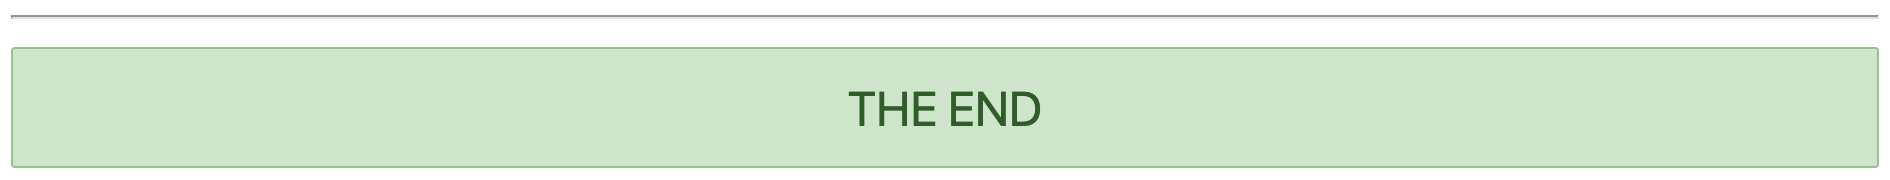